# Exercise 5: Using ggplot

This homework assignment is designed to get you comfortable working with `ggplot` for generating data visualizations.

We will be using the [gapminder](https://cran.r-project.org/web/packages/gapminder/index.html) dataset. It contains  information about population, life expectancy and per capita GDP by country over time.

---
# 1. Color, plot type and layers (6 points)

Install and load the `gapminder` dataset. Look at the first few rows of the data frame.

In [1]:
install.packages("gapminder")
library("gapminder")


The downloaded binary packages are in
	/var/folders/5_/v0q2657s7b354r1303qrlrxw0000gp/T//RtmpXvHpvb/downloaded_packages


In [2]:
head(gapminder)
unique(gapminder$year)

country,continent,year,lifeExp,pop,gdpPercap
<fct>,<fct>,<int>,<dbl>,<int>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453
Afghanistan,Asia,1957,30.332,9240934,820.8530
Afghanistan,Asia,1962,31.997,10267083,853.1007
Afghanistan,Asia,1967,34.020,11537966,836.1971
Afghanistan,Asia,1972,36.088,13079460,739.9811
Afghanistan,Asia,1977,38.438,14880372,786.1134


[1] 1952 1957 1962 1967 1972 1977 1982 1987 1992 1997 2002 2007

Now, let's create a basic scatterplot using `ggplot2` that shows how life expectancy has changed over time.

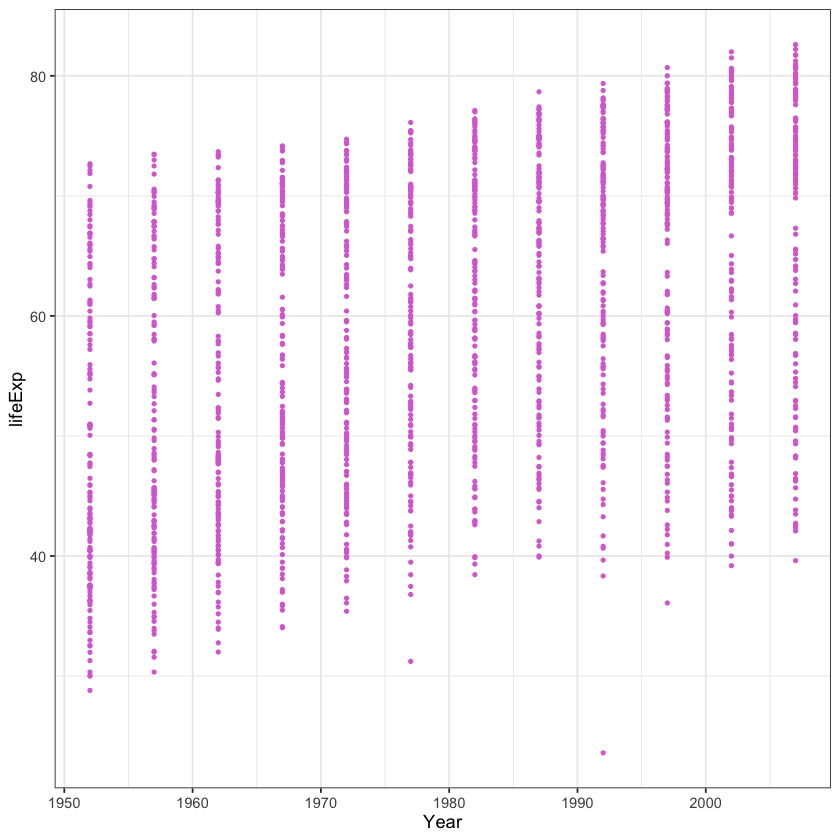

In [48]:
library(tidyverse)

ggplot(gapminder, aes(x = year, y = lifeExp)) + 
    geom_point(size = 0.8, color = 'orchid') +
    scale_x_continuous(name = 'Year') +
    theme_bw()

We can add another layer of detail by using color to indicate continent. Modify the code from the previous question to to do so.

What trends can you identify in the data?

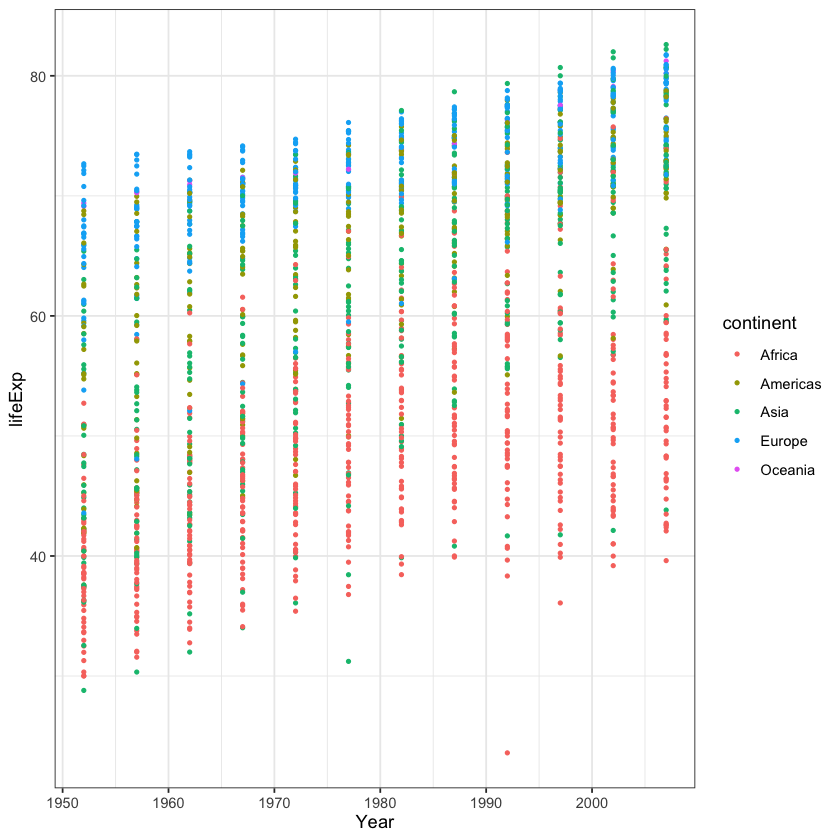

In [25]:
ggplot(gapminder, aes(x = year, y = lifeExp, color = continent)) + 
    geom_point(size = 0.8) +
    scale_x_continuous(name = 'Year') +
    theme_bw()

> * Life expectancy increases over time across all continents. Despite this increase, continents largely maintain their relative rank order. Countries in Asia and Europe also tend to have higher life expectancies overall, although some Asian countries rank among the lowest. Additionally, countries in Africa generally have lower life expectancies and cluster toward the bottom of the distribution.

Using a scatterplot probably isn’t the best type of plot for effectively visualizing change over time. Instead, modify the code from the previous question to create a line plot.

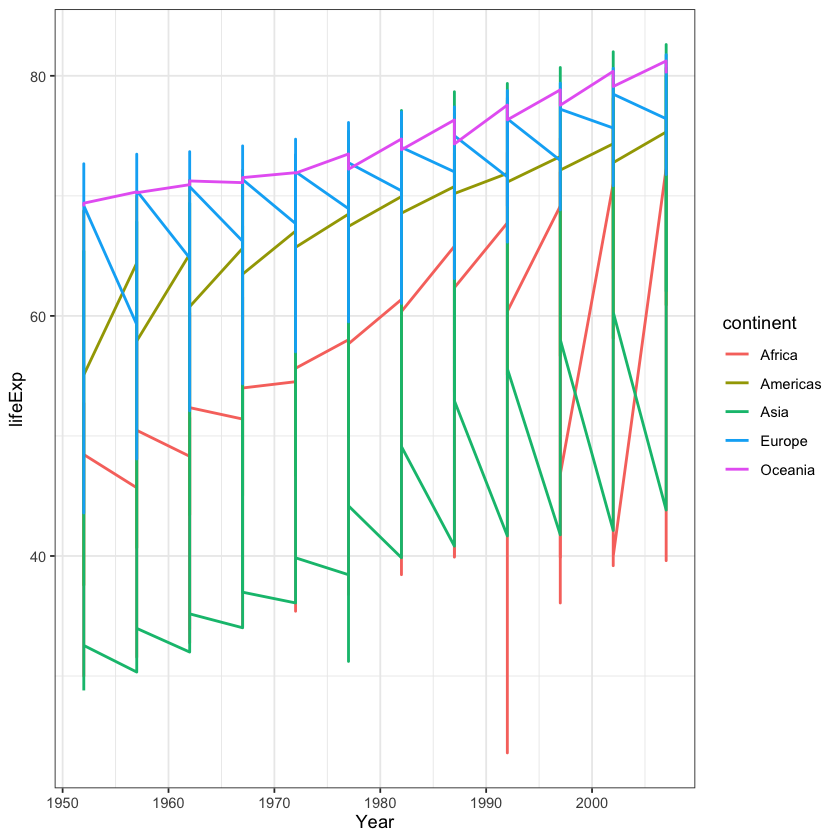

In [26]:
ggplot(gapminder, aes(x = year, y = lifeExp, color = continent)) + 
    geom_line(size = 0.8) +
    scale_x_continuous(name = 'Year') + 
    theme_bw()

Hmm, this plot looks a bit weird and unexpected, making it difficult for us to easily interpret the data trends. What is causing this?

> * Geom_line connects data points, which, in the figure above, forces a relationship between the data observed. It is unclear if a relationship between the data points exist, especially given the variation observed within each continent in the previous graph.

Now, let’s try to separate the data by country, plotting one line for each country. Modify the code from the previous plot to do so.

*Hint: You’ll need to tell ggplot() what variable to use to split the data into separate lines. Look for the argument `by` to specify how the data should be grouped.*

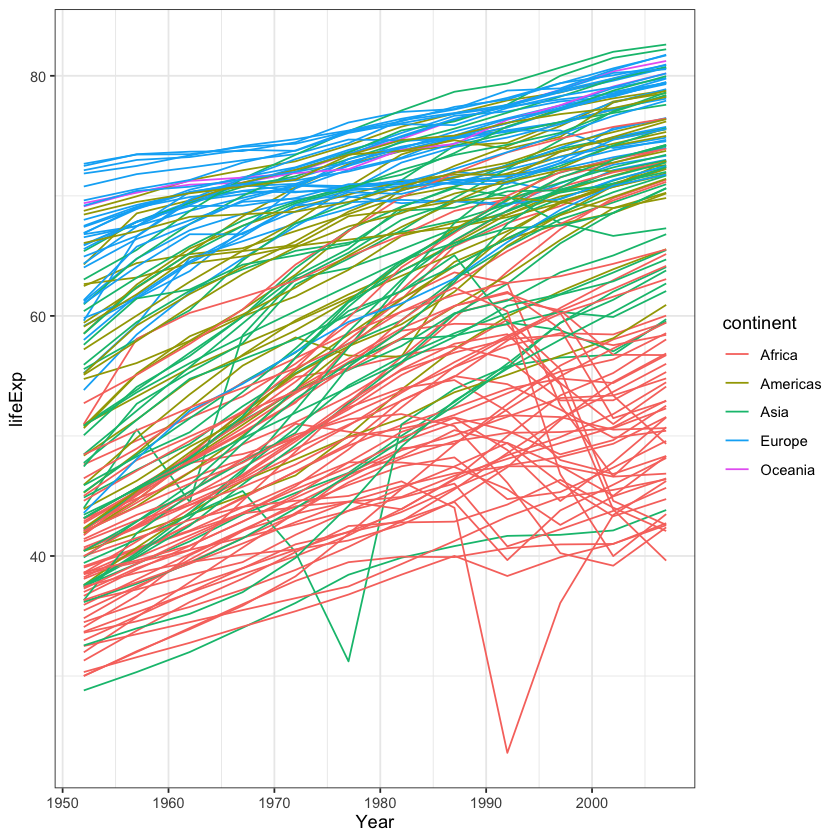

In [27]:
ggplot(gapminder, aes(x = year, y = lifeExp, group = country, color = continent)) + 
    geom_line() +
    scale_x_continuous(name = 'Year') +
    theme_bw()

But what if we want to visualize both lines and points on our graph? There are two primary ways to do this - taking advantage of what we know about using layers for ggplot (each layer is drawn on top of the previous layer).

* Method 1: Plot black points on top of the colorful lines
* Method 2: Plot black points underneath the colorful lines

Modify the code from the previous question to create two plots, one for each method.

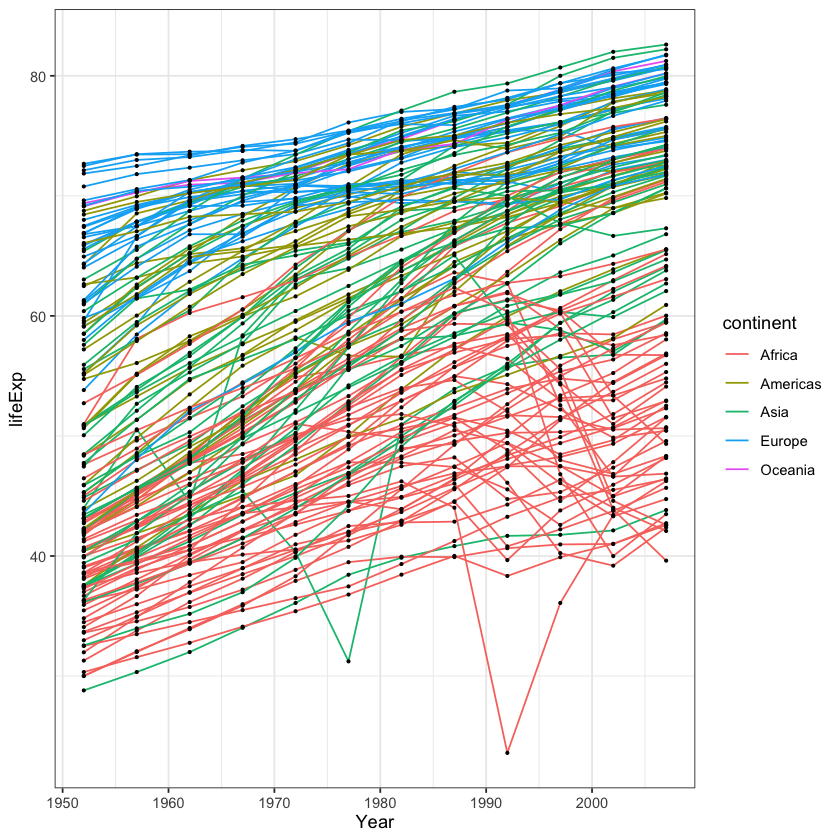

In [30]:
# method 1
ggplot(gapminder, aes(x = year, y = lifeExp, group = country, color = continent)) + 
    geom_line() +
    geom_point(color = 'black', size = 0.5) +
    scale_x_continuous(name = 'Year') +
    theme_bw()

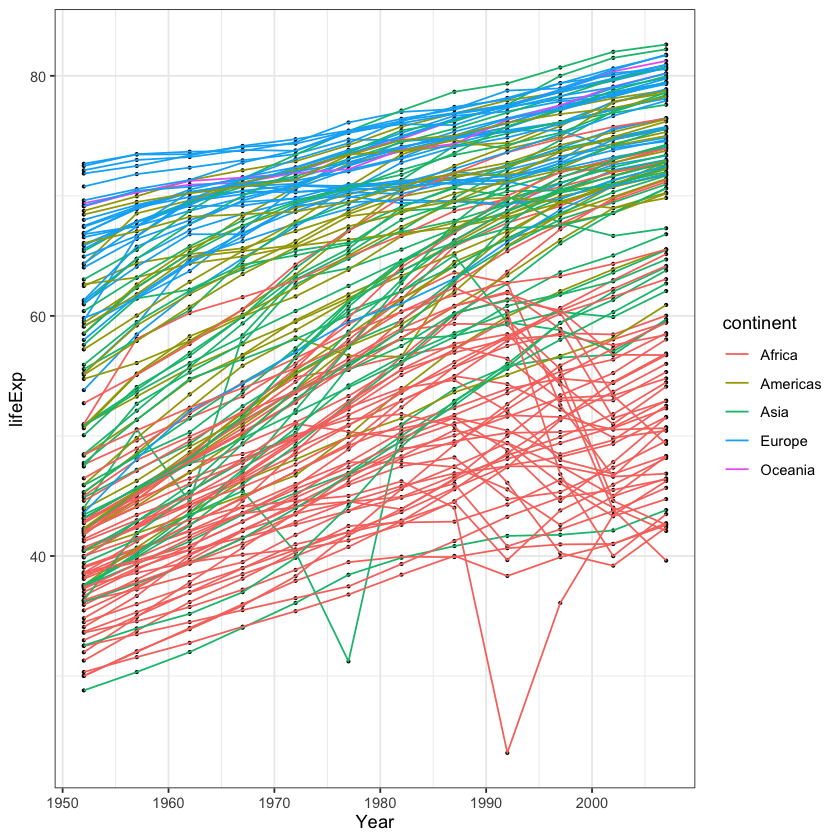

In [31]:
# method 2
ggplot(gapminder, aes(x = year, y = lifeExp, group = country, color = continent)) + 
    geom_point(color = 'black', size = 0.5) +
    geom_line() +
    scale_x_continuous(name = 'Year') +
    theme_bw()

Now modify one of the plots above so that points are also colored by continent (instead of black).

*Hint: to control the color of the points, think about where the aesthetic color attribute should be located e.g., in the global plot options or in a specific layer.*

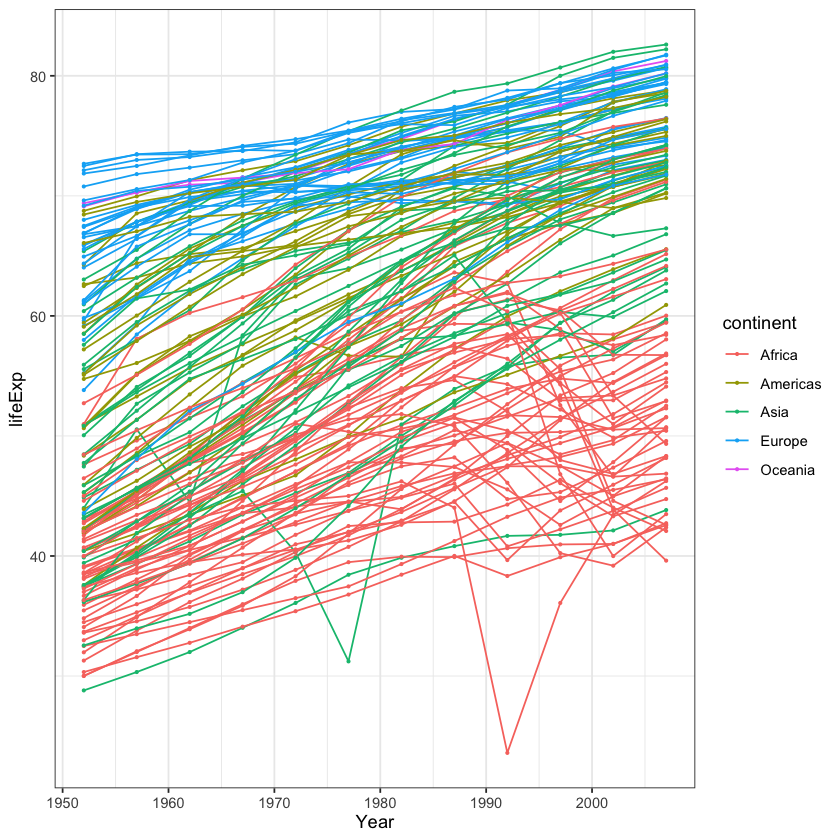

In [32]:
# aside: colorful points
ggplot(gapminder, aes(x = year, y = lifeExp, group = country, color = continent)) + 
    geom_line() +
    geom_point(size = 0.5) +
    scale_x_continuous(name = 'Year') +
    theme_bw()

---
# 2. Adding statistics (4 points)

`ggplot2` allows easy overlay of statistical models on top of the data.

The graph below shows the relationship between life expectency and GDP per capita:

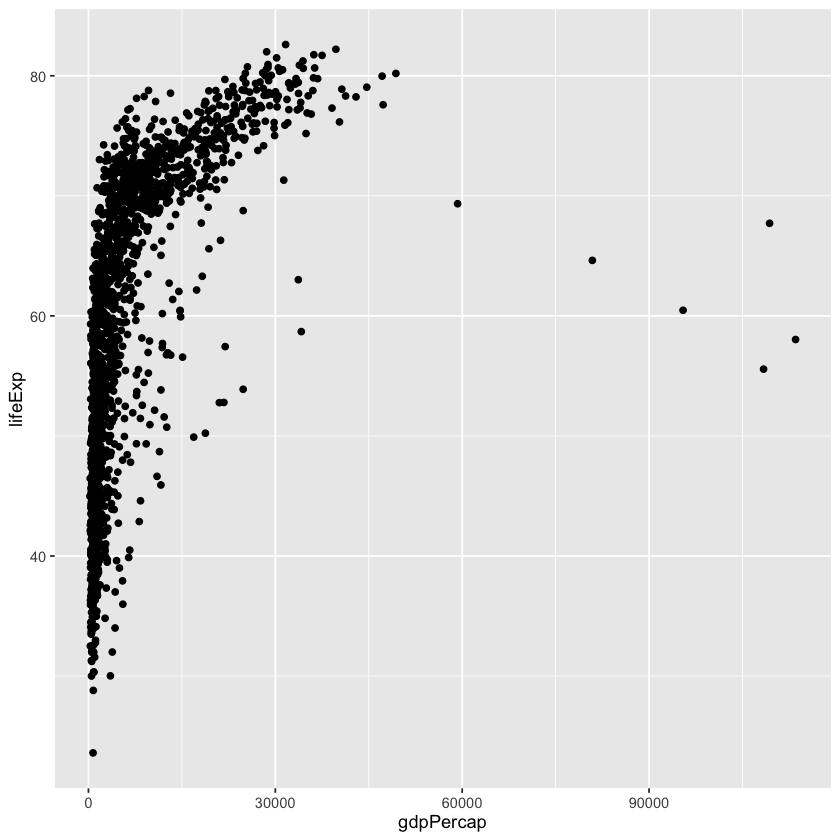

In [33]:
ggplot(data = gapminder, mapping = aes(x = gdpPercap, y = lifeExp)) +
  geom_point()

However, the data points are squished close together on the left side of the graph, so it's hard to see the actual relationship we're interested in.

To fix this, we can change the scale of x-axis units using the scale functions. We can also make the data points transparent using the alpha function. This is helpful when there is a large amount of clustered data.

Modify the code above to incorporate these two changes (scale and transparency).

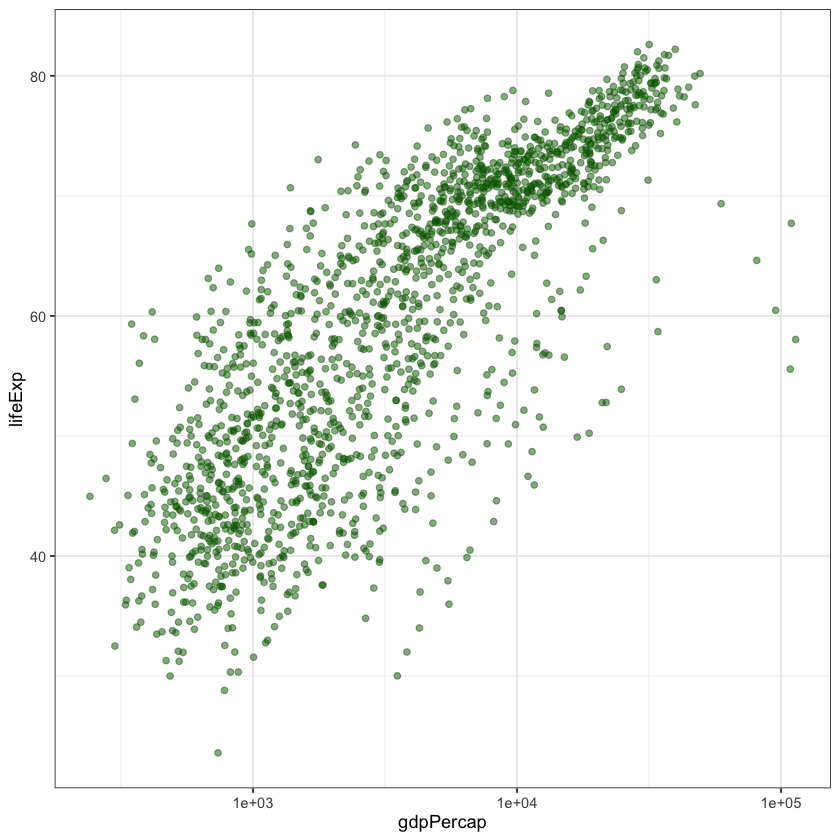

In [44]:
ggplot(data = gapminder, mapping = aes(x = gdpPercap, y = lifeExp)) +
    geom_point(alpha = 0.5, color = 'dark green') +
    scale_x_log10(name = 'gdpPercap') +
    theme_bw()

Already we can more easily visualize the trend in the data.

Next, let's overlay statistics by fiting a simple relationship to the data. Modify the code from the previous question by adding a `geom_smooth` layer.

`geom_smooth()` using formula = 'y ~ x'


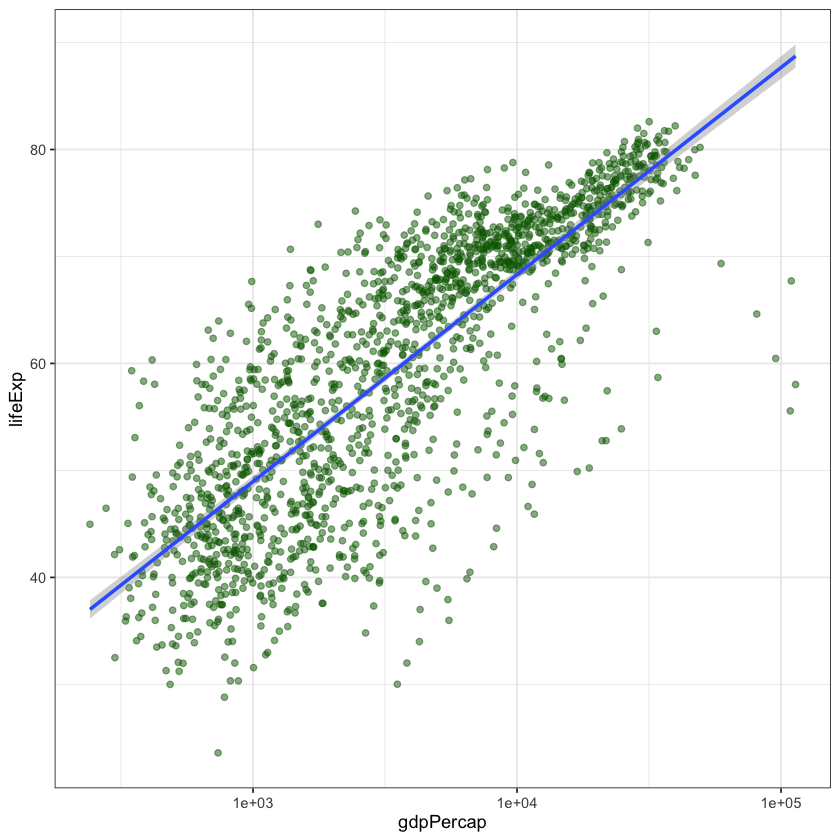

In [45]:
ggplot(data = gapminder, mapping = aes(x = gdpPercap, y = lifeExp)) +
    geom_point(alpha = 0.5, color = 'dark green') +
    geom_smooth(method = 'lm') +
    scale_x_log10(name = 'gdpPercap') +
    theme_bw()

Again, we can add a layer of detail by introducing separate colors for each continent. We can also create individual trendlines for each continent, instead of only one trendline.

Modify the code from the previous question to add these elements.


`geom_smooth()` using formula = 'y ~ x'


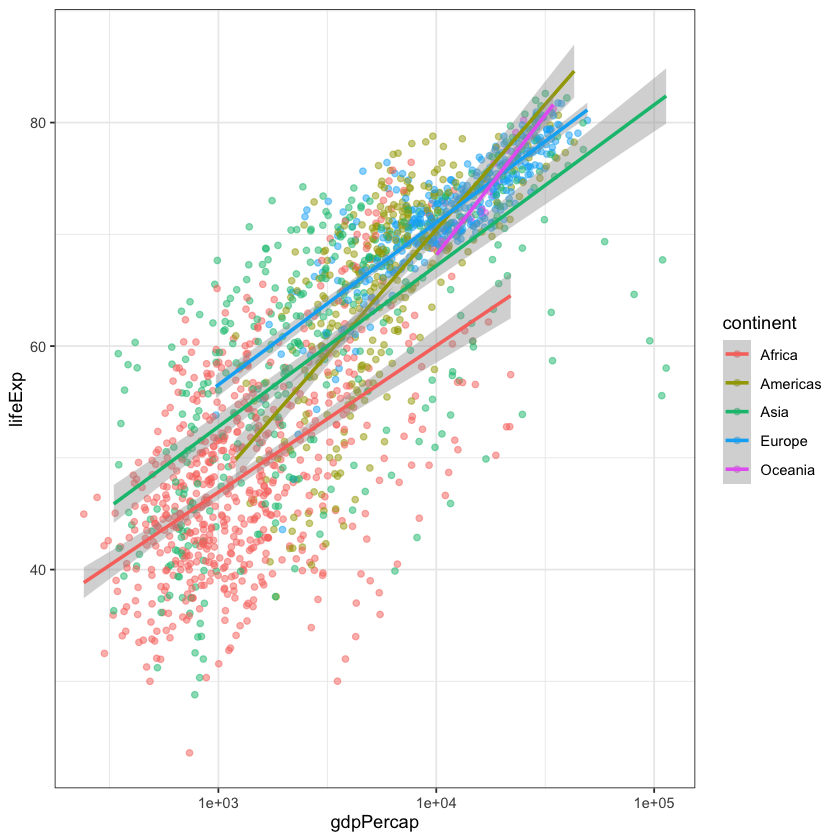

In [46]:
ggplot(data = gapminder, mapping = aes(x = gdpPercap, y = lifeExp, color = continent)) +
    geom_point(alpha = 0.5) +
    geom_smooth(method = 'lm') +
    scale_x_log10(name = 'gdpPercap') +
    theme_bw()

When you are finished, save the notebook as Exercise5.ipynb, push it to your GitHub repository and submit the permanent link to your notebook via Canvas.

**DUE:** 11:59 PM EST, Feb 10, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *I did not collaborate with any of my classmates on this assignment.*